### Import statements

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols
import pandas as pd

## Sensor calibration

### Subcritical sensor calibration curve

b0 = 36.867167582476284
b1 = 2.2729171352478246


Text(0, 0.5, 'Water level (cm)')

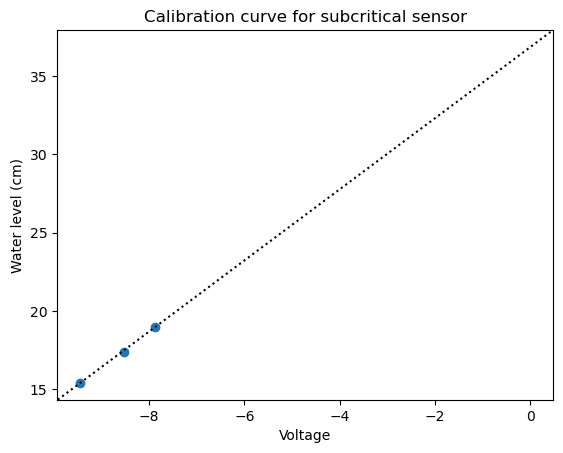

In [18]:
# calibration data
sub_voltage = np.array([-9.4592, -8.5297, -7.8816])
sub_height = np.array([15.4, 17.4, 19])                     # cm
sub_df = pd.DataFrame({'Voltage':sub_voltage, 'Height':sub_height})

# linear fit
sub_calibration = ols('Height ~ Voltage', data=sub_df).fit()
sub_b0, sub_b1 = sub_calibration.params
print(f'b0 = {sub_b0}')
print(f'b1 = {sub_b1}')

# plot
plt.scatter(sub_voltage, sub_height)
plt.axline(xy1=(0,sub_b0), slope=sub_b1, color='black', linestyle=':')
plt.title('Calibration curve for subcritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Supercritical sensor calibration curve

b0 = 28.6137223023922
b1 = 2.2998132138163467


Text(0, 0.5, 'Water level (cm)')

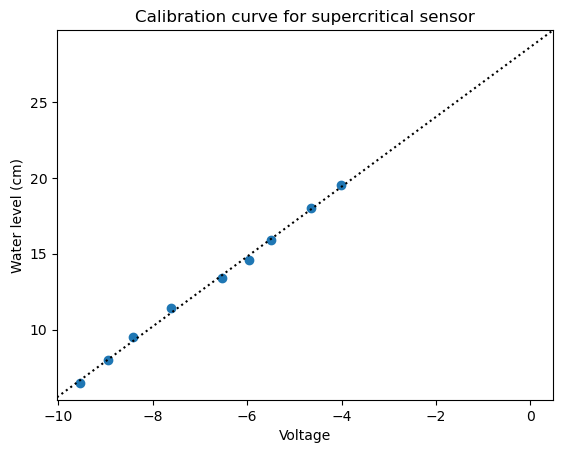

In [17]:
# calibration data
super_voltage = np.array([-9.5491, -8.9420, -8.4136, -7.6184, -6.5391, -5.9702, -5.4983, -4.6409, -4.0175])
super_height = np.array([6.5, 8, 9.5, 11.4, 13.4, 14.6, 15.9, 18, 19.5])    # cm
super_df = pd.DataFrame({'Voltage':super_voltage, 'Height':super_height})

# linear fit
super_calibration = ols('Height ~ Voltage', data=super_df).fit()
super_b0, super_b1 = super_calibration.params
print(f'b0 = {super_b0}')
print(f'b1 = {super_b1}')

# plot
plt.scatter(super_voltage, super_height)
plt.axline(xy1=(0,super_b0), slope=super_b1, color='black', linestyle=':')
plt.title('Calibration curve for supercritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Head tank sensor calibration curve

b0 = 59.58499679931716
b1 = 2.0198975781500033


Text(0, 0.5, 'Water level (cm)')

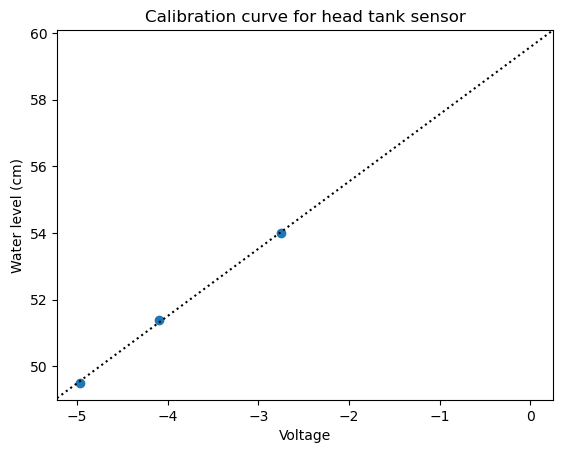

In [21]:
# calibration data
head_voltage = np.array([-2.75, -4.09, -4.97])
head_distance = np.array([9.6, 12.2, 14.1])    # cm, sensor distance from water surface
head_df = pd.DataFrame({'Voltage':head_voltage, 'Distance':head_distance})

# convert distance from water surface to water level
head_df['Height'] = 63.6 - head_df['Distance']

# linear fit
head_calibration = ols('Height ~ Voltage', data=head_df).fit()
head_b0, head_b1 = head_calibration.params
print(f'b0 = {head_b0}')
print(f'b1 = {head_b1}')

# plot
plt.scatter(head_df['Voltage'], head_df['Height'])
plt.axline(xy1=(0,head_b0), slope=head_b1, color='black', linestyle=':')
plt.title('Calibration curve for head tank sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

## Load data

### Read csv files

In [42]:
import glob

csv_files = sorted(glob.glob('*.csv'))
dfs = []

for file_name in csv_files:
    try:
        df = pd.read_csv(file_name)
        dfs.append(df)
        print(f"Successfully read: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

V_ai0 = np.empty(len(csv_files))
V_ai1 = np.empty(len(csv_files))
V_ai2 = np.empty(len(csv_files))

for i, df in enumerate(dfs):
    V_ai0[i] = df['V_ai0'].mean()
    V_ai1[i] = df['V_ai1'].mean()
    V_ai2[i] = df['V_ai2'].mean()

sensor_data = pd.DataFrame({'V_ai0': V_ai0, 'V_ai1': V_ai1, 'V_ai2': V_ai2}) # note that trial indices are one less than the ones I wrote in the notebook

Successfully read: 2025-10-05_22-53-14_sensor_data.csv
Successfully read: 2025-10-05_22-56-31_sensor_data.csv
Successfully read: 2025-10-05_22-59-49_sensor_data.csv
Successfully read: 2025-10-05_23-02-43_sensor_data.csv
Successfully read: 2025-10-05_23-06-24_sensor_data.csv
Successfully read: 2025-10-05_23-09-04_sensor_data.csv
Successfully read: 2025-10-05_23-11-32_sensor_data.csv
Successfully read: 2025-10-05_23-14-20_sensor_data.csv
Successfully read: 2025-10-05_23-17-09_sensor_data.csv
Successfully read: 2025-10-05_23-20-13_sensor_data.csv
Successfully read: 2025-10-05_23-24-35_sensor_data.csv


### Convert voltages to water heights

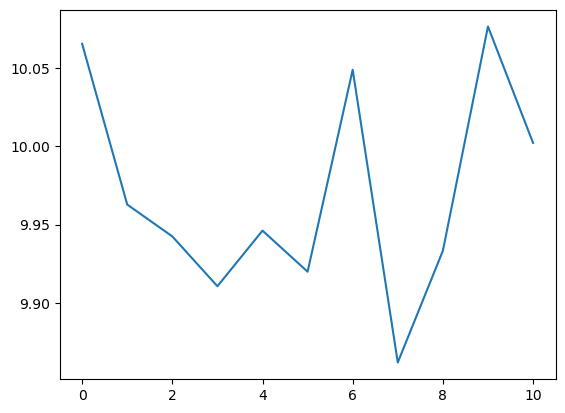

In [45]:
sensor_data['Supercritical Height (cm)'] = super_b0 + super_b1 * sensor_data['V_ai1'] # DOUBLE CHECK IF YOU MATCHED THESE CORRECTLY

plt.plot(sensor_data['Supercritical Height (cm)'])


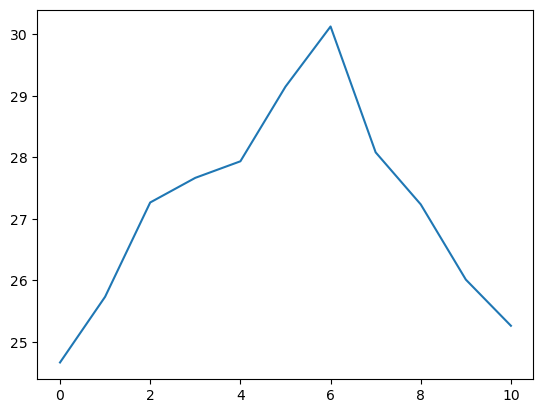

In [46]:
sensor_data['Subcritical Height (cm)'] = sub_b0 + sub_b1 * sensor_data['V_ai0']

plt.plot(sensor_data['Subcritical Height (cm)'])

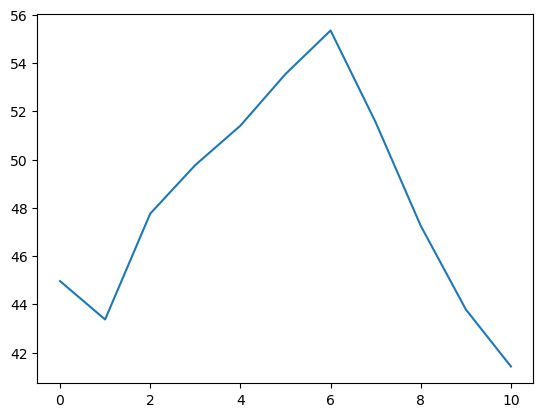

In [47]:
sensor_data['Head Tank Height (cm)'] = head_b0 + head_b1 * sensor_data['V_ai2']

plt.plot(sensor_data['Head Tank Height (cm)'])

### Plot the curves together

Text(0, 0.5, 'Water level (cm)')

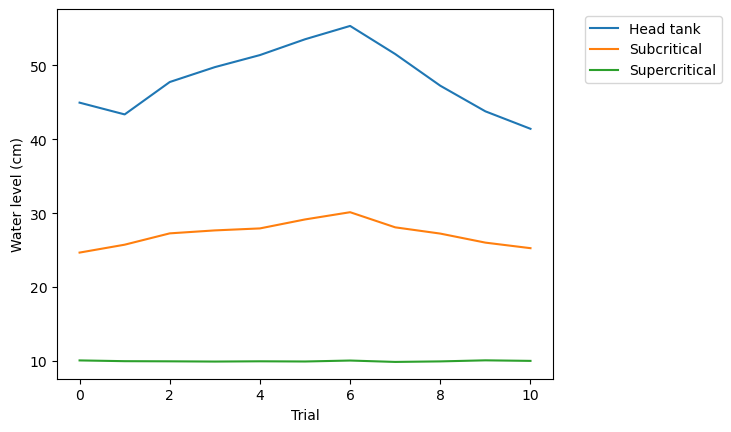

In [55]:
plt.plot(sensor_data['Head Tank Height (cm)'])
plt.plot(sensor_data['Subcritical Height (cm)'])
plt.plot(sensor_data['Supercritical Height (cm)'])


plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')

## Stage discharge curve

### Calculate discharge

In [60]:
sensor_data['Delta P'] = np.array([75, 84, 92, 97, 102, 107, 112, 102, 93, 83, 75]) # from venturi meter
# need to figure out how to get Q from delta P

### Calculate head difference

In [58]:
sensor_data['Head diff (cm)'] = sensor_data['Head Tank Height (cm)'] - sensor_data['Subcritical Height (cm)']

### Graph stage vs discharge 

In [56]:
import seaborn as sns

,V_ai0,V_ai1,V_ai2,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Head diff (cm),Delta P
0,-5.369103,-8.065030,-7.239318,10.065660,24.663641,44.962316,20.298675,75
1,-4.898718,-8.109736,-8.027560,9.962845,25.732788,43.370148,17.637361,84
2,-4.223808,-8.118592,-5.856064,9.942477,27.266802,47.756348,20.489546,92
3,-4.047504,-8.132454,-4.858358,9.910598,27.667526,49.771610,22.104084,97
4,-3.929032,-8.116987,-4.050200,9.946169,27.936802,51.404007,23.467205,102
5,-3.394809,-8.128411,-2.991200,9.919894,29.151049,53.543078,24.392029,107
6,-2.963937,-8.072247,-2.096639,10.049063,30.130384,55.350002,25.219617,112
7,-3.864924,-8.153658,-3.980503,9.861832,28.082516,51.544788,23.462272,102
8,-4.237487,-8.122600,-6.104998,9.933260,27.235712,47.253527,20.017815,93
9,-4.775843,-8.060206,-7.821599,10.076755,26.012071,43.786168,17.774097,83


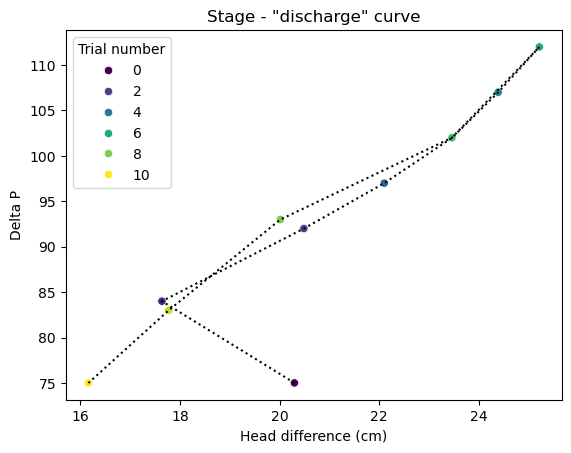

In [77]:
sns.scatterplot(x='Head diff (cm)', y='Delta P', hue=np.arange(0, len(sensor_data)), data=sensor_data, palette='viridis')
plt.plot(sensor_data['Head diff (cm)'], sensor_data['Delta P'], color='black', linestyle=':')
#sns.lineplot(x='Head diff (cm)', y='Delta P', data=sensor_data)
plt.xlabel('Head difference (cm)')
plt.ylabel('Delta P')
plt.legend(title='Trial number')
plt.title('Stage - "discharge" curve')

display(sensor_data)